This file loads soil data into a dataframe to visualize the first map of microplastic concentrations in Trondheim

In [ ]:
from pathlib import Path

import pandas as pd

# Read the workbook from the Data folder into a new DataFrame.
excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
soil_autolabel_df = pd.read_excel(excel_file)

# Rename position columns for autolabel data.
soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

# Build Sample_ID from image values (drop S prefix, leading zeros, and file suffix).
sample_id = (
    soil_autolabel_df["image"]
    .str.extract(r"S0*([0-9]+)", expand=False)
    .astype("Int64")
)

if "Sample_ID" in soil_autolabel_df.columns:
    soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])

soil_autolabel_df.insert(
    soil_autolabel_df.columns.get_loc("image"),
    "Sample_ID",
    sample_id,
)

print(f"Loaded {soil_autolabel_df.shape[0]} rows and {soil_autolabel_df.shape[1]} columns")
soil_autolabel_df.head()

Loaded 61 rows and 14 columns


,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0
1,3,S0003_NR.png,1,2790,2232,19,12,166,31.6860,460.7,584.3,348.5,1.68,1.0.0
2,5,S0005_NR.png,1,2393,1837,19,13,194,31.5871,496.4,599.3,379.0,1.58,1.0.0
3,7,S0007_NR.png,1,2704,2370,9,6,46,31.4438,240.6,259.3,157.2,1.65,1.0.0
4,13,S0013_NR.png,1,1147,1533,14,8,87,31.6065,332.7,412.1,221.2,1.86,1.0.0


In [ ]:
# Create a DataFrame from the ArcGIS Excel file.
arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
soil_arcgis_df = pd.read_excel(arcgis_file)

# Rename coordinate columns for ArcGIS data.
soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

print(f"Loaded {soil_arcgis_df.shape[0]} rows and {soil_arcgis_df.shape[1]} columns")
soil_arcgis_df.head()

Loaded 149 rows and 16 columns


,OBJECTID,GlobalID,place_name,Sample_ID,Date,Region,Notes_Environment_description,Potential plastic sources,Macroplastics observed,Corridor,CreationDate,Creator,EditDate,Editor,x (long),y (lat)
0,4,945cc581-79da-43ff-b98d-be4a5ee18854,Blåbærstupet,33,2026-07-06 08:52:54.373,NaN,"Near the fjord, and pirbadet. Nice view, took ...",NaN,NaN,NaN,2026-07-06 08:56:11.307,senasm_NTNU_2026,2026-07-06 08:56:11.307,senasm_NTNU_2026,10.393289,63.437870
1,5,e06d3d13-f66d-4600-bc4a-5a2101f2d11a,Blåbærstupet,34,2026-07-06 08:58:25.990,NaN,Bad surface. Steinete underlag. Lenger ut på ø...,NaN,NaN,NaN,2026-07-06 09:00:34.346,senasm_NTNU_2026,2026-07-23 11:09:22.922,senasm_NTNU_2026,10.393090,63.437827
2,6,89f31e09-0900-4840-bf5c-85552d9b29c5,Tømmerholt,35,2026-07-06 09:44:18.772,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 09:44:21.112,senasm_NTNU_2026,2026-07-28 12:08:41.925,senasm_NTNU_2026,10.474053,63.390331
3,7,dcdcbd55-ab5d-4aa0-9a7c-6fa9c4deda52,Tømmerholt,36,2026-07-06 09:49:43.006,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 09:49:45.957,senasm_NTNU_2026,2026-07-28 12:08:48.678,senasm_NTNU_2026,10.476196,63.390851
4,8,3cba7106-9609-4837-aa45-06c720e12df1,Tømmerholt,37,2026-07-06 10:00:00.000,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 10:04:29.694,frehau_NTNU_2026,2026-07-28 12:08:50.742,senasm_NTNU_2026,10.479347,63.392105


In [ ]:
# Start with the first DataFrame and add matching coordinates from the second DataFrame.
coords_by_sample = (
    soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
    .dropna(subset=["Sample_ID"])
    .drop_duplicates(subset=["Sample_ID"], keep="first")
)

soil_autolabel_with_coords_df = soil_autolabel_df.merge(
    coords_by_sample,
    on="Sample_ID",
    how="left",
)

print(
    f"Created dataframe with {soil_autolabel_with_coords_df.shape[0]} rows and "
    f"{soil_autolabel_with_coords_df.shape[1]} columns"
)
soil_autolabel_with_coords_df.head()

Created dataframe with 61 rows and 16 columns


,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version,x (long),y (lat)
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0,10.405113,63.419756
1,3,S0003_NR.png,1,2790,2232,19,12,166,31.6860,460.7,584.3,348.5,1.68,1.0.0,10.405279,63.419811
2,5,S0005_NR.png,1,2393,1837,19,13,194,31.5871,496.4,599.3,379.0,1.58,1.0.0,10.397522,63.421440
3,7,S0007_NR.png,1,2704,2370,9,6,46,31.4438,240.6,259.3,157.2,1.65,1.0.0,10.396640,63.423140
4,13,S0013_NR.png,1,1147,1533,14,8,87,31.6065,332.7,412.1,221.2,1.86,1.0.0,10.386079,63.429519


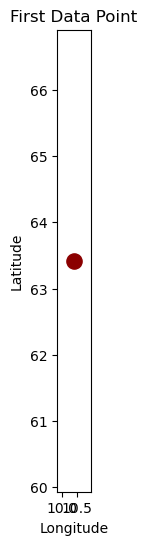

,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version,x (long),y (lat),geometry
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0,10.405113,63.419756,POINT (10.40511 63.41976)


In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

if "soil_autolabel_with_coords_df" not in globals():
    excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
    soil_autolabel_df = pd.read_excel(excel_file)
    soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

    sample_id = (
        soil_autolabel_df["image"]
        .str.extract(r"S0*([0-9]+)", expand=False)
        .astype("Int64")
    )
    if "Sample_ID" in soil_autolabel_df.columns:
        soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])
    soil_autolabel_df.insert(soil_autolabel_df.columns.get_loc("image"), "Sample_ID", sample_id)

    arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
    soil_arcgis_df = pd.read_excel(arcgis_file)
    soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

    coords_by_sample = (
        soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
        .dropna(subset=["Sample_ID"])
        .drop_duplicates(subset=["Sample_ID"], keep="first")
    )
    soil_autolabel_with_coords_df = soil_autolabel_df.merge(
        coords_by_sample,
        on="Sample_ID",
        how="left",
    )

first_point_df = soil_autolabel_with_coords_df.dropna(subset=["x (long)", "y (lat)"]).iloc[[0]].copy()

first_point_gdf = gpd.GeoDataFrame(
    first_point_df,
    geometry=gpd.points_from_xy(first_point_df["x (long)"], first_point_df["y (lat)"]),
    crs="EPSG:4326",
)

ax = first_point_gdf.plot(figsize=(6, 6), color="darkred", markersize=120)
ax.set_title("First Data Point")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

first_point_gdf

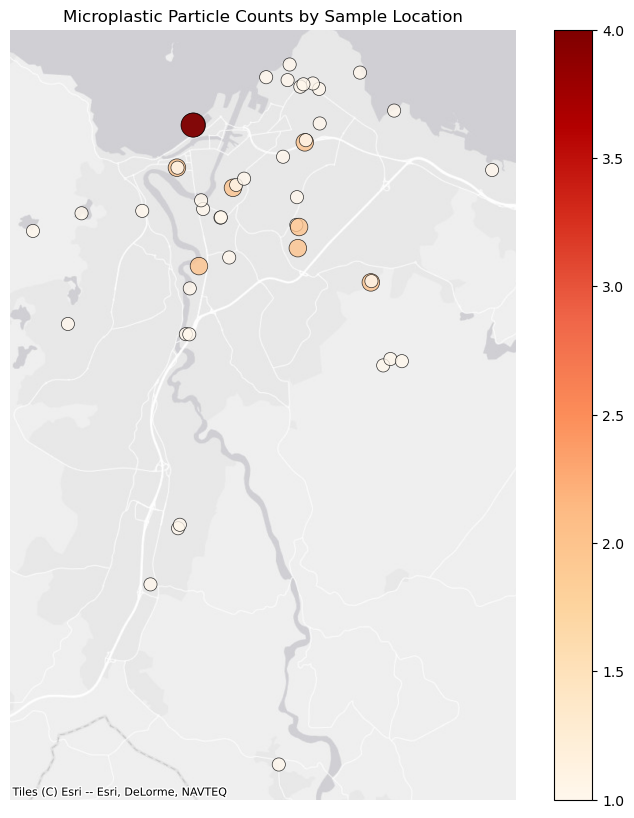

,Sample_ID,x (long),y (lat),particle_count,geometry
0,2,10.405113,63.419756,1,POINT (10.40511 63.41976)
1,3,10.405279,63.419811,1,POINT (10.40528 63.41981)
2,5,10.397522,63.421440,1,POINT (10.39752 63.42144)
3,7,10.396640,63.423140,1,POINT (10.39664 63.42314)
4,13,10.386079,63.429519,2,POINT (10.38608 63.42952)


In [5]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

if "soil_autolabel_with_coords_df" not in globals():
    excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
    soil_autolabel_df = pd.read_excel(excel_file)
    soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

    sample_id = (
        soil_autolabel_df["image"]
        .str.extract(r"S0*([0-9]+)", expand=False)
        .astype("Int64")
    )
    if "Sample_ID" in soil_autolabel_df.columns:
        soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])
    soil_autolabel_df.insert(soil_autolabel_df.columns.get_loc("image"), "Sample_ID", sample_id)

    arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
    soil_arcgis_df = pd.read_excel(arcgis_file)
    soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

    coords_by_sample = (
        soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
        .dropna(subset=["Sample_ID"])
        .drop_duplicates(subset=["Sample_ID"], keep="first")
    )
    soil_autolabel_with_coords_df = soil_autolabel_df.merge(
        coords_by_sample,
        on="Sample_ID",
        how="left",
    )

soil_particle_counts_gdf = (
    soil_autolabel_with_coords_df
    .dropna(subset=["x (long)", "y (lat)"])
    .groupby(["Sample_ID", "x (long)", "y (lat)"], as_index=False)["particle"]
    .nunique()
    .rename(columns={"particle": "particle_count"})
)

soil_particle_counts_gdf = gpd.GeoDataFrame(
    soil_particle_counts_gdf,
    geometry=gpd.points_from_xy(
        soil_particle_counts_gdf["x (long)"],
        soil_particle_counts_gdf["y (lat)"],
    ),
    crs="EPSG:4326",
)

soil_particle_counts_webmerc = soil_particle_counts_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
soil_particle_counts_webmerc.plot(
    ax=ax,
    column="particle_count",
    cmap="OrRd",
    legend=True,
    markersize=soil_particle_counts_webmerc["particle_count"] * 70 + 20,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("Microplastic Particle Counts by Sample Location")
ax.set_axis_off()
plt.show()

soil_particle_counts_gdf.head()